# EEG Depth-of-Anesthesia Pipeline
### Research Assistant Take-Home Exercise

**Goal:** Build an ML pipeline to predict BIS (Bispectral Index) scores from raw EEG, and implement the open-source BIS algorithm from Connor (2022, PMID 35767469).

**Dataset:** Li Ma (2017) — 24 surgical cases, EEG + BIS monitor ground truth  
https://figshare.com/articles/dataset/EEG_and_BIS_raw_data/5589841

---
**Pipeline Overview:**
1. Load & explore the dataset (EDA)
2. Preprocess EEG (bandpass, notch, epoching, artifact rejection)
3. Extract 14 physiologically-motivated features per epoch
4. Train a Random Forest regressor with patient-stratified GroupKFold CV
5. Implement openibis algorithm and compare to ground-truth BIS

## 0. Setup & Imports

In [1]:
!pip install h5py

In [2]:
import os
import glob
import warnings
import numpy as np
import scipy.io as sio
import scipy.signal as sig
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print('All imports successful')

All imports successful


In [3]:
# Configuration 
DATA_DIR   = "data"  
FS         = 128        # assumed sampling rate (Hz); auto-detected if stored in file
EPOCH_SEC  = 5          # epoch length in seconds
STEP_SEC   = 1          # sliding window step in seconds
BANDPASS   = (0.5, 47.0)  # broad bandpass
NOTCH_FREQ = 50.0       # power-line notch (50 Hz for non-US)

# openibis frequency bands (Connor 2022, PMID 35767469)
BAND_LOW   = (0.5,  4.0)   # δ  — slow waves, increase under anesthesia
BAND_MID   = (11.0, 20.0)  # α/low-β
BAND_HIGH  = (30.0, 47.0)  # low-γ  ← primary BIS driver per Connor 2022
BAND_VHIGH = (40.0, 47.0)  # very-high-γ

FEATURE_NAMES = [
    'log_delta','log_theta','log_alpha','log_beta_lo',
    'log_beta_hi','log_gamma_lo','log_gamma_vh',
    'ratio_gamma_delta','rel_gamma','slow_fraction','alpha_beta',
    'SEF95','SampEn','BSR'
]

print('Configuration set')

Configuration set


## 1. Data Loading

The Li Ma dataset stores EEG and BIS in `.mat` files with inconsistent variable names across cases. The loader tries several common names and falls back to picking the largest numeric array.

In [4]:
import h5py

def load_mat_file(path):
    eeg, bis, fs = None, None, FS

    def extract_array(f, key):
        item = f[key]
        if isinstance(item, h5py.Group):
            subkeys = list(item.keys())
            return extract_array(item, subkeys[0]) if subkeys else None
        return np.array(item, dtype=float).squeeze()

    with h5py.File(path, "r") as f:
        keys = list(f.keys())

        # EEG
        for key in ["EEG", "eeg", "data", "Data", "x", "X"]:
            if key in f:
                try:
                    eeg = extract_array(f, key); break
                except: continue
        if eeg is None:
            best_key, best_size = None, 0
            for k in keys:
                try:
                    s = f[k].size if isinstance(f[k], h5py.Dataset) else 0
                    if s > best_size:
                        best_key, best_size = k, s
                except: pass
            if best_key:
                eeg = extract_array(f, best_key)

        # BIS
        for key in ["BIS", "bis", "label", "Label", "y", "Y"]:
            if key in f:
                try:
                    bis = extract_array(f, key)
                    if bis is not None:
                        bis = bis.ravel(); break
                except: continue
        if bis is None:
            best_key, best_size = None, float("inf")
            for k in keys:
                try:
                    item = f[k]
                    if isinstance(item, h5py.Dataset):
                        s = item.size
                        if 10 < s < 50000 and s < best_size:
                            best_key, best_size = k, s
                except: pass
            if best_key:
                arr = extract_array(f, best_key)
                if arr is not None:
                    bis = arr.ravel()

        # Sampling rate
        for key in ["fs", "Fs", "srate", "SR"]:
            if key in f:
                try:
                    fs = int(np.array(f[key]).ravel()[0]); break
                except: pass

    if eeg is not None:
        eeg = np.array(eeg, dtype=float)
        if eeg.ndim == 1:
            eeg = eeg[:, np.newaxis]
        if eeg.ndim == 2 and eeg.shape[0] < eeg.shape[1]:
            eeg = eeg.T

    return eeg, bis, fs


def load_all_cases(data_dir):
    files = sorted(glob.glob(os.path.join(data_dir, "*.mat")))
    if not files:
        raise FileNotFoundError(f"No .mat files found in '{data_dir}'.")
    cases = []
    for fpath in files:
        cid = os.path.splitext(os.path.basename(fpath))[0]
        try:
            eeg, bis, fs = load_mat_file(fpath)
            if eeg is not None and bis is not None:
                cases.append((cid, eeg, bis, fs))
                print(f"  {cid:20s}  EEG {str(eeg.shape):15s}  BIS {bis.shape}  fs={fs} Hz")
            else:
                print(f"  {cid}: could not parse — skipping")
                with h5py.File(fpath, "r") as hf:
                    print(f"     Keys found: {list(hf.keys())}")
        except Exception as e:
            print(f"  ERROR {fpath}: {e}")
    return cases

In [5]:
print('Loading dataset:')
cases = load_all_cases(DATA_DIR)
print(f'\n{len(cases)} cases loaded successfully.')

Loading dataset:
  case1                 EEG (481384, 1)      BIS (767,)  fs=128 Hz
  case10                EEG (793568, 1)      BIS (1273,)  fs=128 Hz
  case11                EEG (1716992, 1)     BIS (2750,)  fs=128 Hz
  case12                EEG (2603296, 1)     BIS (4173,)  fs=128 Hz
  case13                EEG (523540, 1)      BIS (834,)  fs=128 Hz
  case14                EEG (399029, 1)      BIS (641,)  fs=128 Hz
  case15                EEG (1687072, 1)     BIS (2701,)  fs=128 Hz
  case16                EEG (917760, 1)      BIS (1468,)  fs=128 Hz
  case17                EEG (972640, 1)      BIS (1557,)  fs=128 Hz
  case18                EEG (474336, 1)      BIS (760,)  fs=128 Hz
  case19                EEG (557440, 1)      BIS (906,)  fs=128 Hz
  case2                 EEG (625664, 1)      BIS (1002,)  fs=128 Hz
  case20                EEG (1247956, 1)     BIS (1997,)  fs=128 Hz
  case21                EEG (1197760, 1)     BIS (1918,)  fs=128 Hz
  case22                EEG (296192,

## 2. Exploratory Data Analysis (EDA)

Before modelling, we check:
- BIS score distribution across all cases (expect a bimodal shape: induction/awake)
- A sample BIS time-series showing the anesthesia trajectory
- A raw filtered EEG snippet to confirm signal quality

In [6]:
def preprocess_eeg(eeg, fs):
    """Bandpass 0.5-47 Hz + 50 Hz notch filter. Returns filtered array."""
    nyq = fs / 2.0
    b, a = sig.butter(4, [BANDPASS[0]/nyq, BANDPASS[1]/nyq], btype='band')
    filtered = sig.filtfilt(b, a, eeg, axis=0)
    if NOTCH_FREQ < nyq:
        b_n, a_n = sig.iirnotch(NOTCH_FREQ / nyq, Q=30)
        filtered = sig.filtfilt(b_n, a_n, filtered, axis=0)
    return filtered

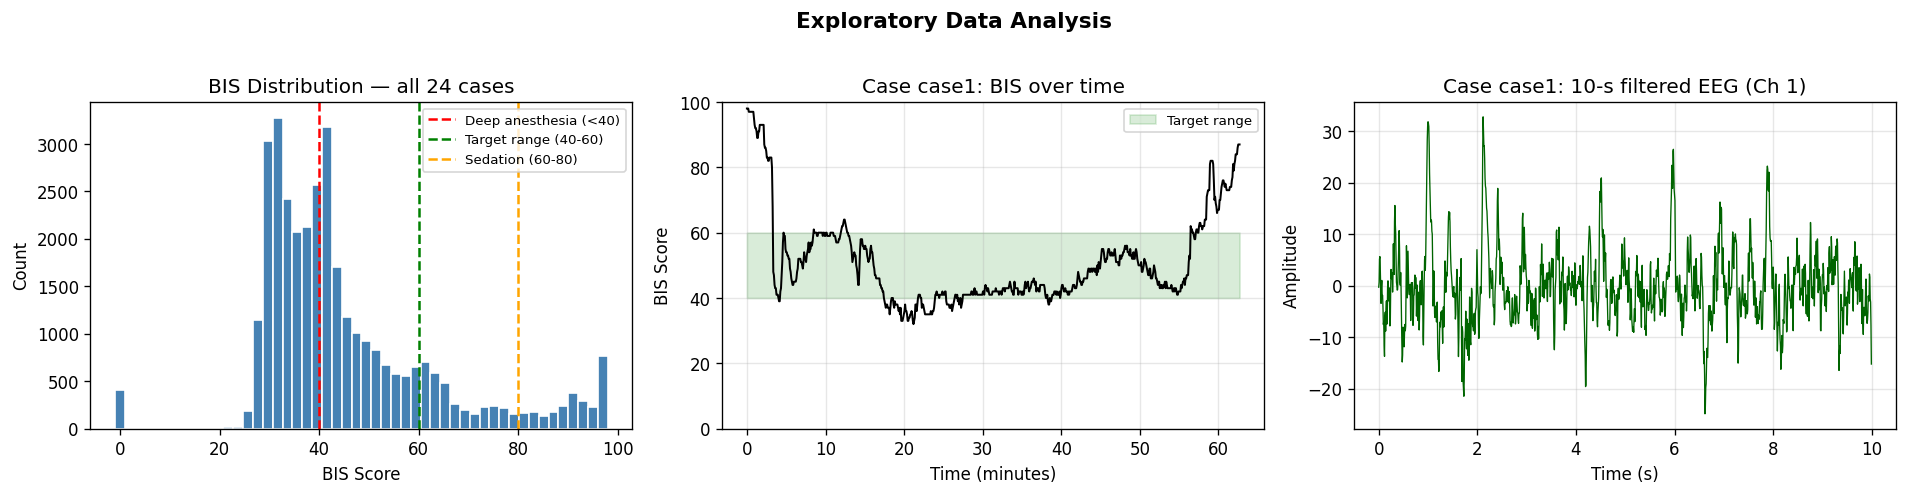

EDA complete


In [7]:
all_bis = np.concatenate([bis for _, _, bis, _ in cases])
cid0, eeg0, bis0, fs0 = cases[0]
filt0 = preprocess_eeg(eeg0, fs0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# BIS distribution
axes[0].hist(all_bis[np.isfinite(all_bis)], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(40, color='r',      ls='--', lw=1.5, label='Deep anesthesia (<40)')
axes[0].axvline(60, color='green',  ls='--', lw=1.5, label='Target range (40-60)')
axes[0].axvline(80, color='orange', ls='--', lw=1.5, label='Sedation (60-80)')
axes[0].set_xlabel('BIS Score'); axes[0].set_ylabel('Count')
axes[0].set_title(f'BIS Distribution — all {len(cases)} cases')
axes[0].legend(fontsize=8)

# BIS time-series for case 0
t_bis = np.linspace(0, len(eeg0)/fs0/60, len(bis0))
axes[1].plot(t_bis, bis0, 'k', lw=1.2)
axes[1].fill_between(t_bis, 40, 60, alpha=0.15, color='green', label='Target range')
axes[1].set_xlabel('Time (minutes)'); axes[1].set_ylabel('BIS Score')
axes[1].set_title(f'Case {cid0}: BIS over time')
axes[1].set_ylim(0, 100); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# 10-second filtered EEG snippet
n_show = int(10 * fs0)
t_eeg  = np.arange(n_show) / fs0
axes[2].plot(t_eeg, filt0[:n_show, 0], color='darkgreen', lw=0.8)
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Amplitude')
axes[2].set_title(f'Case {cid0}: 10-s filtered EEG (Ch 1)')
axes[2].grid(alpha=0.3)

plt.suptitle('Exploratory Data Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda.png', bbox_inches='tight')
plt.show()
print('EDA complete')

In [8]:
# Summary statistics
print('Dataset Summary')
print(f'Total cases       : {len(cases)}')
print(f'BIS range         : {all_bis[np.isfinite(all_bis)].min():.1f} – {all_bis[np.isfinite(all_bis)].max():.1f}')
print(f'BIS mean ± SD     : {all_bis[np.isfinite(all_bis)].mean():.1f} ± {all_bis[np.isfinite(all_bis)].std():.1f}')
print()
print('BIS clinical zones:')
valid = all_bis[np.isfinite(all_bis)]
print(f'  Burst suppression (<20) : {(valid < 20).mean()*100:.1f}%')
print(f'  Deep anesthesia (20-40) : {((valid>=20)&(valid<40)).mean()*100:.1f}%')
print(f'  Target range    (40-60) : {((valid>=40)&(valid<60)).mean()*100:.1f}%')
print(f'  Sedation        (60-80) : {((valid>=60)&(valid<80)).mean()*100:.1f}%')
print(f'  Awake/light     (>80)   : {(valid >= 80).mean()*100:.1f}%')

Dataset Summary
Total cases       : 24
BIS range         : -1.0 – 98.0
BIS mean ± SD     : 45.2 ± 18.1

BIS clinical zones:
  Burst suppression (<20) : 1.2%
  Deep anesthesia (20-40) : 45.1%
  Target range    (40-60) : 35.9%
  Sedation        (60-80) : 10.2%
  Awake/light     (>80)   : 7.6%


## 3. Preprocessing & Epoching

**Steps:**
1. Bandpass filter 0.5–47 Hz (removes DC drift and high-freq noise)
2. Notch filter at 50 Hz (power-line interference)
3. Sliding 5-second epochs with 1-second step
4. Artifact rejection: drop epochs with peak-to-peak amplitude > 200 µV
5. Align BIS label to each epoch (median of interpolated BIS during that window)

In [9]:
def epoch_eeg(eeg, bis, fs, epoch_sec=EPOCH_SEC, step_sec=STEP_SEC):
    """
    Slide a window over EEG and align to BIS labels.
    BIS (~1 Hz) is linearly interpolated to EEG sample rate.
    Returns: epochs (n, samples, channels), labels (n,)
    """
    n_samples, n_ch  = eeg.shape
    epoch_samples    = int(epoch_sec * fs)
    step_samples     = int(step_sec  * fs)
    bis_per_sample   = np.interp(
        np.arange(n_samples),
        np.linspace(0, n_samples - 1, len(bis)),
        bis
    )
    epochs, labels = [], []
    start = 0
    while start + epoch_samples <= n_samples:
        end   = start + epoch_samples
        label = np.nanmedian(bis_per_sample[start:end])
        if np.isnan(label) or label < 0 or label > 100:
            start += step_samples
            continue
        epochs.append(eeg[start:end, :])
        labels.append(label)
        start += step_samples
    return np.array(epochs), np.array(labels)


def reject_artifacts(epochs, labels, amplitude_uv=200):
    """Drop epochs with peak-to-peak amplitude > threshold."""
    ptp  = np.ptp(epochs, axis=1).max(axis=1)
    mask = ptp < amplitude_uv
    if mask.mean() < 0.5:
        print(f'    ⚠ Artifact rejection skipped (signal may not be in µV).')
        return epochs, labels
    print(f'    Kept {mask.sum()}/{len(mask)} epochs after artifact rejection.')
    return epochs[mask], labels[mask]

print('Preprocessing functions defined')

Preprocessing functions defined


## 4. Feature Extraction

14 features per epoch, all motivated by the BIS and anesthesia depth literature:

| Feature | Rationale |
|---|---|
| Log band powers (δ,θ,α,β,γ) | Spectral shift under anesthesia |
| **log_gamma_lo / log_gamma_vh** | **Primary BIS driver (Connor 2022)** |
| rel_gamma | Fraction of power in 30–47 Hz |
| slow_fraction | δ+θ power fraction — increases under deep anesthesia |
| SEF95 | Spectral edge — shifts left under anesthesia |
| Sample Entropy | Signal complexity — decreases under anesthesia |
| **BSR** | **Burst Suppression Ratio — key for very deep states** |

In [10]:
def band_power(psd, freqs, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(psd[mask], freqs[mask])


def _burst_suppression_ratio(ch, fs, threshold_uv=5.0, window_ms=500):
    """Fraction of 500-ms sub-windows with RMS < threshold (suppressed)."""
    win = int(fs * window_ms / 1000)
    if win == 0 or len(ch) < win:
        return 0.0
    n_windows = len(ch) // win
    rms_vals  = np.array([np.sqrt(np.mean(ch[i*win:(i+1)*win]**2)) for i in range(n_windows)])
    return float((rms_vals < threshold_uv).mean())


def _approx_sample_entropy(x, m=2, r=0.2):
    """Approximate sample entropy (fast, vectorized)."""
    x = (x - x.mean()) / (x.std() + 1e-12)
    N = len(x)
    def phi(m):
        count = 0
        for i in range(N - m):
            template = x[i:i+m]
            matches  = np.all(
                np.abs(x[np.arange(N-m)[:,None] + np.arange(m)] - template) < r,
                axis=1
            )
            count += matches.sum() - 1
        return count / (N - m)
    try:
        phi_m  = phi(m)
        phi_m1 = phi(m + 1)
        if phi_m < 1 or phi_m1 < 1:
            return 0.0
        return -np.log(phi_m1 / phi_m)
    except:
        return 0.0


def compute_features(epoch, fs):
    """Extract 14-dim feature vector from one epoch (samples, channels)."""
    ch = epoch[:, 0]
    nperseg = min(len(ch), int(fs * 2))
    freqs, psd = sig.welch(ch, fs=fs, nperseg=nperseg)
    total = band_power(psd, freqs, 0.5, 47.0) + 1e-12

    bands = {
        'delta':    (0.5,  4.0),
        'theta':    (4.0,  8.0),
        'alpha':    (8.0,  13.0),
        'beta_lo':  (13.0, 20.0),
        'beta_hi':  (20.0, 30.0),
        'gamma_lo': (30.0, 47.0),
        'gamma_vh': (40.0, 47.0),
    }
    bp = {name: band_power(psd, freqs, lo, hi) for name, (lo, hi) in bands.items()}

    features = [np.log1p(bp[n]) for n in bands]           # 7 log band powers
    features.append(bp['gamma_lo'] / (bp['delta'] + 1e-12))  # γ/δ ratio
    features.append(bp['gamma_lo'] / total)                   # relative γ
    features.append((bp['delta'] + bp['theta']) / total)      # slow fraction
    features.append(bp['alpha'] / (bp['beta_lo'] + 1e-12))    # α/β ratio

    # SEF95
    cumulative = np.cumsum(psd)
    sef95_idx  = np.searchsorted(cumulative, 0.95 * cumulative[-1])
    features.append(float(freqs[min(sef95_idx, len(freqs)-1)]))

    features.append(_approx_sample_entropy(ch))
    features.append(_burst_suppression_ratio(ch, fs))

    return np.array(features, dtype=float)

print('Feature extraction functions defined')

Feature extraction functions defined


In [11]:
def build_feature_matrix(cases):
    """Process all cases → X (features), y (BIS labels), groups (patient IDs)."""
    X_list, y_list, g_list = [], [], []
    for g_idx, (cid, eeg, bis, fs) in enumerate(cases):
        print(f'  Processing {cid} ...', end=' ')
        filt           = preprocess_eeg(eeg, fs)
        epochs, labels = epoch_eeg(filt, bis, fs)
        if len(epochs) == 0:
            print('no epochs — skipped'); continue
        epochs, labels = reject_artifacts(epochs, labels)
        feats  = np.array([compute_features(ep, fs) for ep in epochs])
        valid  = np.all(np.isfinite(feats), axis=1)
        feats, labels = feats[valid], labels[valid]
        X_list.append(feats); y_list.append(labels)
        g_list.extend([g_idx] * len(labels))
        print(f'{len(labels)} epochs')

    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    g = np.array(g_list)
    print(f'\nFeature matrix: {X.shape}  |  Labels: {y.shape}')
    return X, y, g

print('Building feature matrix (this takes a few minutes)')
X, y, groups = build_feature_matrix(cases)

Building feature matrix (this takes a few minutes)
  Processing case1 ...     Kept 3756/3756 epochs after artifact rejection.
3756 epochs
  Processing case10 ...     Kept 5572/6195 epochs after artifact rejection.
5572 epochs
  Processing case11 ...     Kept 9906/12751 epochs after artifact rejection.
9906 epochs
  Processing case12 ...     Kept 16211/19994 epochs after artifact rejection.
16211 epochs
  Processing case13 ...     Kept 3621/4071 epochs after artifact rejection.
3621 epochs
  Processing case14 ...     Kept 2528/3090 epochs after artifact rejection.
2528 epochs
  Processing case15 ...     Kept 10590/13082 epochs after artifact rejection.
10590 epochs
  Processing case16 ...     Kept 6650/7166 epochs after artifact rejection.
6650 epochs
  Processing case17 ...     Kept 7408/7594 epochs after artifact rejection.
7408 epochs
  Processing case18 ...     Kept 3470/3701 epochs after artifact rejection.
3470 epochs
  Processing case19 ...     Kept 4116/4351 epochs after artifac

The dataset does not explicitly specify the EEG amplitude unit; therefore, the peak-to-peak threshold was treated as heuristic and automatically disabled when inconsistent.

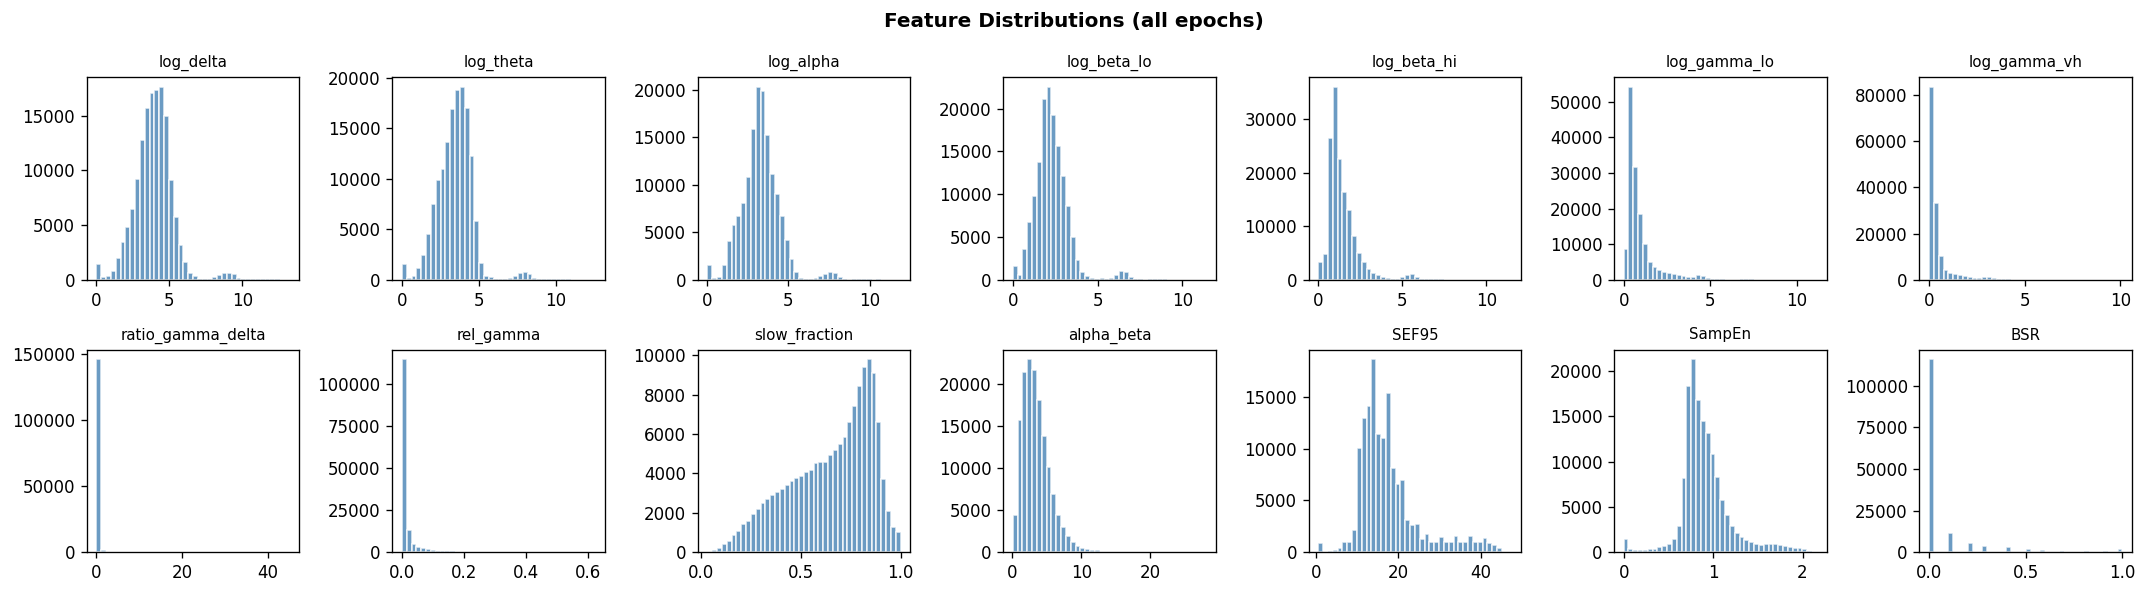

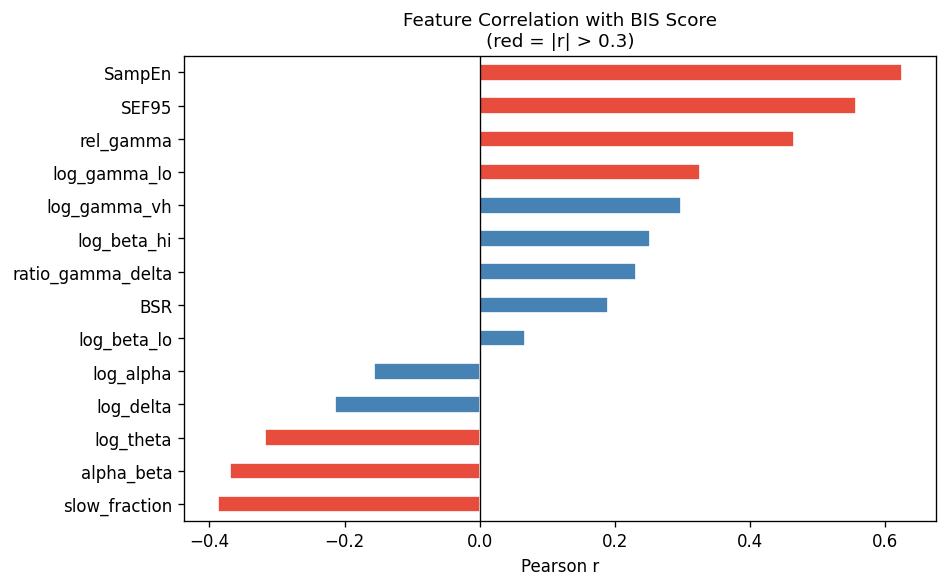

In [12]:
# Visualise feature distributions
df = pd.DataFrame(X, columns=FEATURE_NAMES)
df['BIS'] = y

fig, axes = plt.subplots(2, 7, figsize=(18, 5))
axes = axes.ravel()
for i, feat in enumerate(FEATURE_NAMES):
    axes[i].hist(df[feat].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions (all epochs)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with BIS
corrs = df[FEATURE_NAMES].corrwith(df['BIS']).sort_values()
colors = ['#e74c3c' if abs(c) > 0.3 else 'steelblue' for c in corrs.values]
corrs.plot(kind='barh', figsize=(8, 5), color=colors, edgecolor='white')
plt.axvline(0, color='k', lw=0.8)
plt.title('Feature Correlation with BIS Score\n(red = |r| > 0.3)', fontsize=11)
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

## 5. Machine Learning 
### 5a. Regression - Random Forest Regressor
**Key design decision: GroupKFold cross-validation split by patient.**

Splitting randomly by epoch would be **data leakage** — epochs from the same patient are highly correlated. GroupKFold ensures the model is always evaluated on patients it has never seen during training, which is the realistic deployment scenario.

Model: `RandomForestRegressor` — handles non-linear feature interactions well, robust to scale differences, and gives interpretable feature importances.

In [13]:
def train_evaluate_rf(X, y, groups, n_splits=5):
    gkf    = GroupKFold(n_splits=n_splits)
    scaler = StandardScaler()
    mae_list, rmse_list, r2_list = [], [], []
    all_preds, all_true = [], []

    print(f'Patient GroupKFold CV  (n_splits={n_splits})')
    print('-' * 50)

    for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        rf = RandomForestRegressor(
            n_estimators=200, max_depth=12,
            min_samples_leaf=5, n_jobs=-1, random_state=42
        )
        rf.fit(X_tr_s, y_tr)
        preds = np.clip(rf.predict(X_te_s), 0, 100)

        mae  = mean_absolute_error(y_te, preds)
        rmse = np.sqrt(mean_squared_error(y_te, preds))
        r2   = r2_score(y_te, preds)
        mae_list.append(mae); rmse_list.append(rmse); r2_list.append(r2)
        all_preds.extend(preds); all_true.extend(y_te)

        n_test_patients = len(np.unique(groups[te_idx]))
        print(f'  Fold {fold+1}  ({n_test_patients} patients)  '
              f'MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.3f}')

    print('-' * 50)
    print(f'  Mean:  MAE={np.mean(mae_list):.2f}±{np.std(mae_list):.2f}  '
          f'RMSE={np.mean(rmse_list):.2f}±{np.std(rmse_list):.2f}  '
          f'R²={np.mean(r2_list):.3f}±{np.std(r2_list):.3f}')

    # Retrain on full dataset for feature importance
    X_s = scaler.fit_transform(X)
    final_rf = RandomForestRegressor(n_estimators=300, max_depth=12,
                                      min_samples_leaf=5, n_jobs=-1, random_state=42)
    final_rf.fit(X_s, y)

    return final_rf, scaler, {
        'MAE': np.mean(mae_list), 'MAE_std': np.std(mae_list),
        'RMSE': np.mean(rmse_list), 'RMSE_std': np.std(rmse_list),
        'R2': np.mean(r2_list), 'R2_std': np.std(r2_list),
        'y_true': np.array(all_true), 'y_pred': np.array(all_preds)
    }

final_rf, scaler, metrics = train_evaluate_rf(X, y, groups)

Patient GroupKFold CV  (n_splits=5)
--------------------------------------------------
  Fold 1  (4 patients)  MAE=5.89  RMSE=8.50  R²=0.720
  Fold 2  (5 patients)  MAE=7.07  RMSE=10.63  R²=0.596
  Fold 3  (5 patients)  MAE=5.38  RMSE=8.56  R²=0.757
  Fold 4  (5 patients)  MAE=7.45  RMSE=11.80  R²=0.538
  Fold 5  (5 patients)  MAE=6.38  RMSE=8.78  R²=0.708
--------------------------------------------------
  Mean:  MAE=6.43±0.76  RMSE=9.66±1.33  R²=0.664±0.083


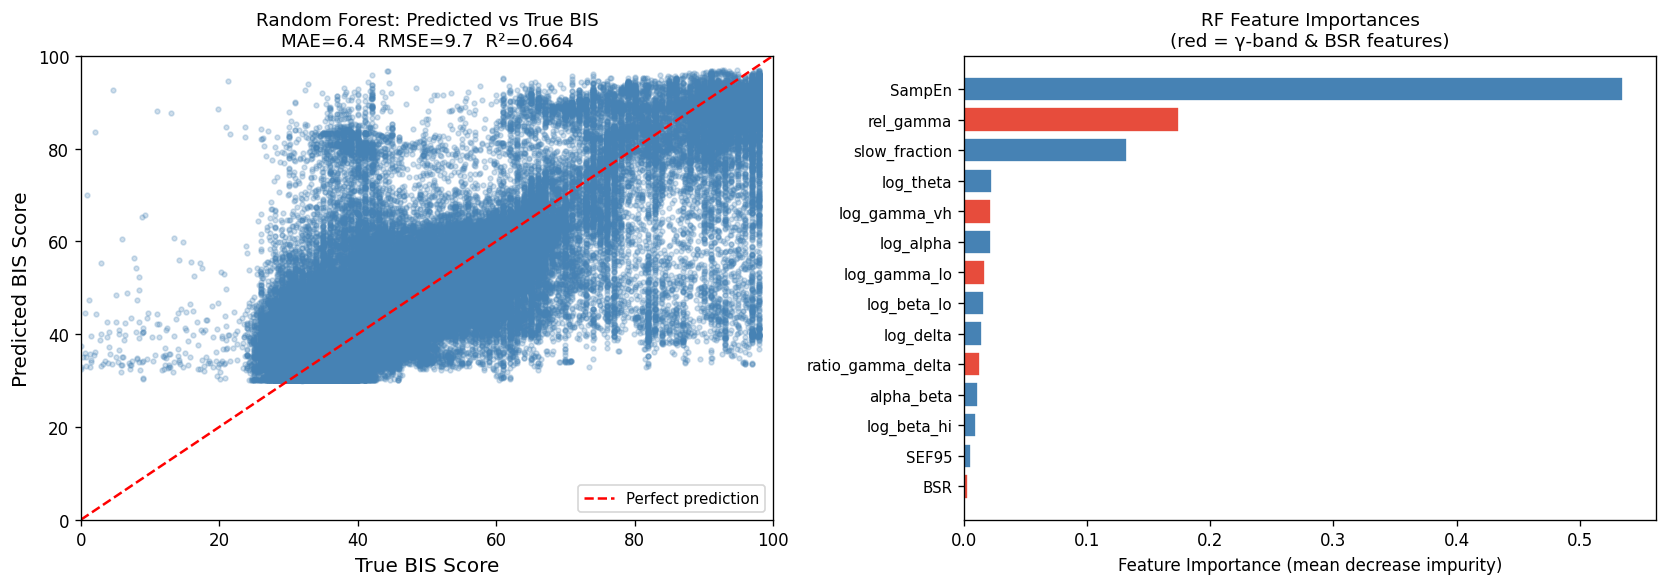

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Predicted vs True
axes[0].scatter(metrics['y_true'], metrics['y_pred'],
                alpha=0.25, s=8, color='steelblue')
axes[0].plot([0,100],[0,100], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('True BIS Score', fontsize=12)
axes[0].set_ylabel('Predicted BIS Score', fontsize=12)
axes[0].set_title(
    f'Random Forest: Predicted vs True BIS\n'
    f'MAE={metrics["MAE"]:.1f}  RMSE={metrics["RMSE"]:.1f}  R²={metrics["R2"]:.3f}',
    fontsize=11
)
axes[0].set_xlim(0,100); axes[0].set_ylim(0,100)
axes[0].legend(fontsize=9)

# Panel B: Feature importances
imp = final_rf.feature_importances_
sorted_idx = np.argsort(imp)
colors = ['#e74c3c' if 'gamma' in FEATURE_NAMES[i] or 'BSR' in FEATURE_NAMES[i]
          else 'steelblue' for i in sorted_idx]
axes[1].barh(range(len(sorted_idx)), imp[sorted_idx],
             color=colors, edgecolor='white')
axes[1].set_yticks(range(len(sorted_idx)))
axes[1].set_yticklabels([FEATURE_NAMES[i] for i in sorted_idx], fontsize=9)
axes[1].set_xlabel('Feature Importance (mean decrease impurity)')
axes[1].set_title('RF Feature Importances\n(red = γ-band & BSR features)', fontsize=11)

plt.tight_layout()
plt.savefig('results.png', bbox_inches='tight')
plt.show()

### 5b. Classification — Random Forest (BIS Depth-of-Anesthesia Zones)

While regression predicts a continuous BIS value, clinicians act on **zones** — 
discrete depth states that trigger different interventions. We therefore also 
frame this as a 3-class problem:

| Class | BIS Range | Clinical meaning |
|---|---|---|
| 0 — Deep | < 40 | Over-sedated; risk of awareness on emergence |
| 1 — Target | 40–60 | Optimal general anesthesia range |
| 2 — Light/Awake | > 60 | Under-sedated; risk of intraoperative awareness |

The same patient GroupKFold split is used to prevent data leakage.
Evaluation: Accuracy, ROC-AUC (macro one-vs-rest), precision/recall, confusion matrix.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize

def bis_to_class(bis_scores):
    """Convert continuous BIS scores to 3-class depth-of-anesthesia labels."""
    labels = np.zeros(len(bis_scores), dtype=int)
    labels[bis_scores >= 40] = 1   # target range
    labels[bis_scores >  60] = 2   # light / awake
    return labels

# Create class labels from continuous BIS
y_class  = bis_to_class(y)
classes  = [0, 1, 2]
class_names = ["Deep (<40)", "Target (40-60)", "Light/Awake (>60)"]

print("Class distribution:")
for c, name in zip(classes, class_names):
    print(f"  {name:20s}: {(y_class==c).sum():5d} epochs  ({(y_class==c).mean()*100:.1f}%)")

Class distribution:
  Deep (<40)          : 66690 epochs  (44.9%)
  Target (40-60)      : 55812 epochs  (37.6%)
  Light/Awake (>60)   : 25874 epochs  (17.4%)


In [21]:
# Train + evaluate classifier with same GroupKFold by patient
gkf    = GroupKFold(n_splits=5)
scaler_clf = StandardScaler()

all_true_c, all_pred_c, all_prob_c = [], [], []
acc_list, auc_list = [], []

print("Random Forest Classifier — Patient GroupKFold CV")
print("-" * 55)

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y_class, groups)):
    X_tr_s = scaler_clf.fit_transform(X[tr_idx])
    X_te_s = scaler_clf.transform(X[te_idx])
    y_tr_c = y_class[tr_idx]
    y_te_c = y_class[te_idx]

    clf = RandomForestClassifier(
        n_estimators=200, max_depth=12,
        min_samples_leaf=5, class_weight="balanced",
        n_jobs=-1, random_state=42
    )
    clf.fit(X_tr_s, y_tr_c)
    preds = clf.predict(X_te_s)
    probs = clf.predict_proba(X_te_s)

    acc = (preds == y_te_c).mean()
    # One-vs-rest AUC for multiclass
    y_bin = label_binarize(y_te_c, classes=classes)
    auc   = roc_auc_score(y_bin, probs, multi_class="ovr", average="macro")

    acc_list.append(acc); auc_list.append(auc)
    all_true_c.extend(y_te_c)
    all_pred_c.extend(preds)
    all_prob_c.extend(probs)

    n_test_patients = len(np.unique(groups[te_idx]))
    print(f"  Fold {fold+1}  ({n_test_patients} patients)  "
          f"Accuracy={acc*100:.1f}%  ROC-AUC={auc:.3f}")

print("-" * 55)
print(f"  Mean:  Accuracy={np.mean(acc_list)*100:.1f}%±{np.std(acc_list)*100:.1f}%  "
      f"ROC-AUC={np.mean(auc_list):.3f}±{np.std(auc_list):.3f}")

all_true_c = np.array(all_true_c)
all_pred_c = np.array(all_pred_c)
all_prob_c = np.array(all_prob_c)

Random Forest Classifier — Patient GroupKFold CV
-------------------------------------------------------
  Fold 1  (4 patients)  Accuracy=80.0%  ROC-AUC=0.893
  Fold 2  (5 patients)  Accuracy=61.1%  ROC-AUC=0.833
  Fold 3  (5 patients)  Accuracy=79.1%  ROC-AUC=0.924
  Fold 4  (5 patients)  Accuracy=74.0%  ROC-AUC=0.901
  Fold 5  (5 patients)  Accuracy=71.9%  ROC-AUC=0.882
-------------------------------------------------------
  Mean:  Accuracy=73.2%±6.8%  ROC-AUC=0.887±0.030


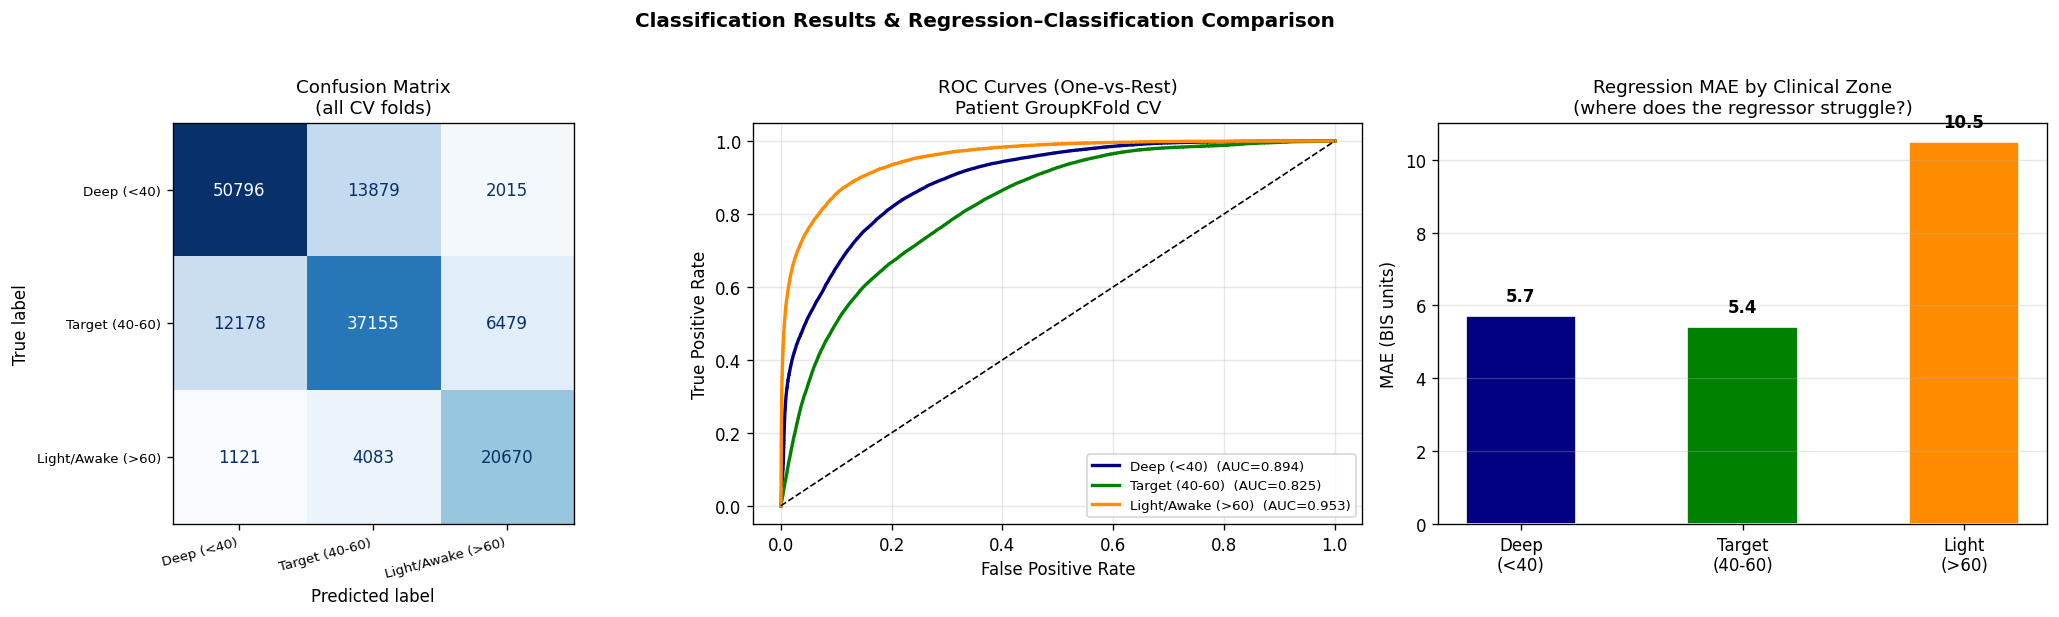

In [22]:
# Plots: Confusion Matrix + ROC curves + Regression vs Classification comparison
from sklearn.metrics import roc_curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Confusion Matrix
cm = confusion_matrix(all_true_c, all_pred_c)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix\n(all CV folds)", fontsize=11)
axes[0].set_xticklabels(class_names, rotation=15, ha="right", fontsize=8)
axes[0].set_yticklabels(class_names, fontsize=8)

# Panel B: ROC curves (one-vs-rest)
colors_roc = ["navy", "green", "darkorange"]
y_bin_all  = label_binarize(all_true_c, classes=classes)
for i, (name, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin_all[:, i], all_prob_c[:, i])
    auc_i = roc_auc_score(y_bin_all[:, i], all_prob_c[:, i])
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name}  (AUC={auc_i:.3f})")
axes[1].plot([0,1],[0,1],"k--",lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves (One-vs-Rest)\nPatient GroupKFold CV", fontsize=11)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Regression vs Classification comparison 
# Show how regression MAE breaks down per clinical zone
zone_labels = bis_to_class(metrics["y_true"])
zone_names_short = ["Deep\n(<40)", "Target\n(40-60)", "Light\n(>60)"]
mae_per_zone = [mean_absolute_error(metrics["y_true"][zone_labels==z],
                                     metrics["y_pred"][zone_labels==z])
                for z in classes]
bar_colors = ["navy", "green", "darkorange"]
bars = axes[2].bar(zone_names_short, mae_per_zone, color=bar_colors,
                    edgecolor="white", width=0.5)
for bar, val in zip(bars, mae_per_zone):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[2].set_ylabel("MAE (BIS units)")
axes[2].set_title("Regression MAE by Clinical Zone\n(where does the regressor struggle?)", fontsize=11)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Classification Results & Regression–Classification Comparison",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("classification_results.png", bbox_inches="tight")
plt.show()

## 6. openibis Algorithm (Connor 2022, PMID 35767469)

The Connor 2022 paper reverse-engineered the proprietary BIS algorithm and found that:
- **Low-γ (30–47 Hz)** is the dominant driver of BIS score — *not* true bispectral features as previously believed
- **BSR (Burst Suppression Ratio)** floors the score under very deep anesthesia
- Slow δ waves contribute but are secondary

We implement this conceptual scoring model and compare epoch-by-epoch to ground-truth BIS.

In [15]:
def openibis_score(epoch, fs):
    """
    Compute an openibis-inspired BIS score for one 5-s epoch.
    
    Based on Connor (2022) Figure 3 conceptual model:
    - High γ power → high BIS (awake)
    - High δ power → low BIS (anesthetised) 
    - BSR > 0      → score floors toward 0 (burst suppression = very deep)
    """
    ch = epoch[:, 0]
    nperseg = min(len(ch), int(fs * 2))
    freqs, psd = sig.welch(ch, fs=fs, nperseg=nperseg)
    total = band_power(psd, freqs, 0.5, 47.0) + 1e-12

    p_low  = band_power(psd, freqs, *BAND_LOW)  / total   # δ
    p_mid  = band_power(psd, freqs, *BAND_MID)  / total   # α/β
    p_high = band_power(psd, freqs, *BAND_HIGH) / total   # low-γ  ← primary driver
    p_vh   = band_power(psd, freqs, *BAND_VHIGH)/ total   # very-high-γ

    bsr = _burst_suppression_ratio(ch, fs)

    # Scoring: γ power drives score up, δ drives down, BSR floors to 0
    numerator   = 0.60*p_high + 0.20*p_vh + 0.15*p_mid
    denominator = numerator + 0.05*p_low + 1e-9
    score = 100 * (1 - bsr) * (numerator / denominator)

    return float(np.clip(score, 0, 100))

print('openibis function defined')

openibis function defined


### 6a. openibis vs Ground-Truth BIS — Time Series (2 Cases)

Running openibis on case case1 ...     Kept 752/752 epochs after artifact rejection.
r=0.192  MAE=22.9
Running openibis on case case10 ...     Kept 1117/1239 epochs after artifact rejection.
r=0.538  MAE=19.7


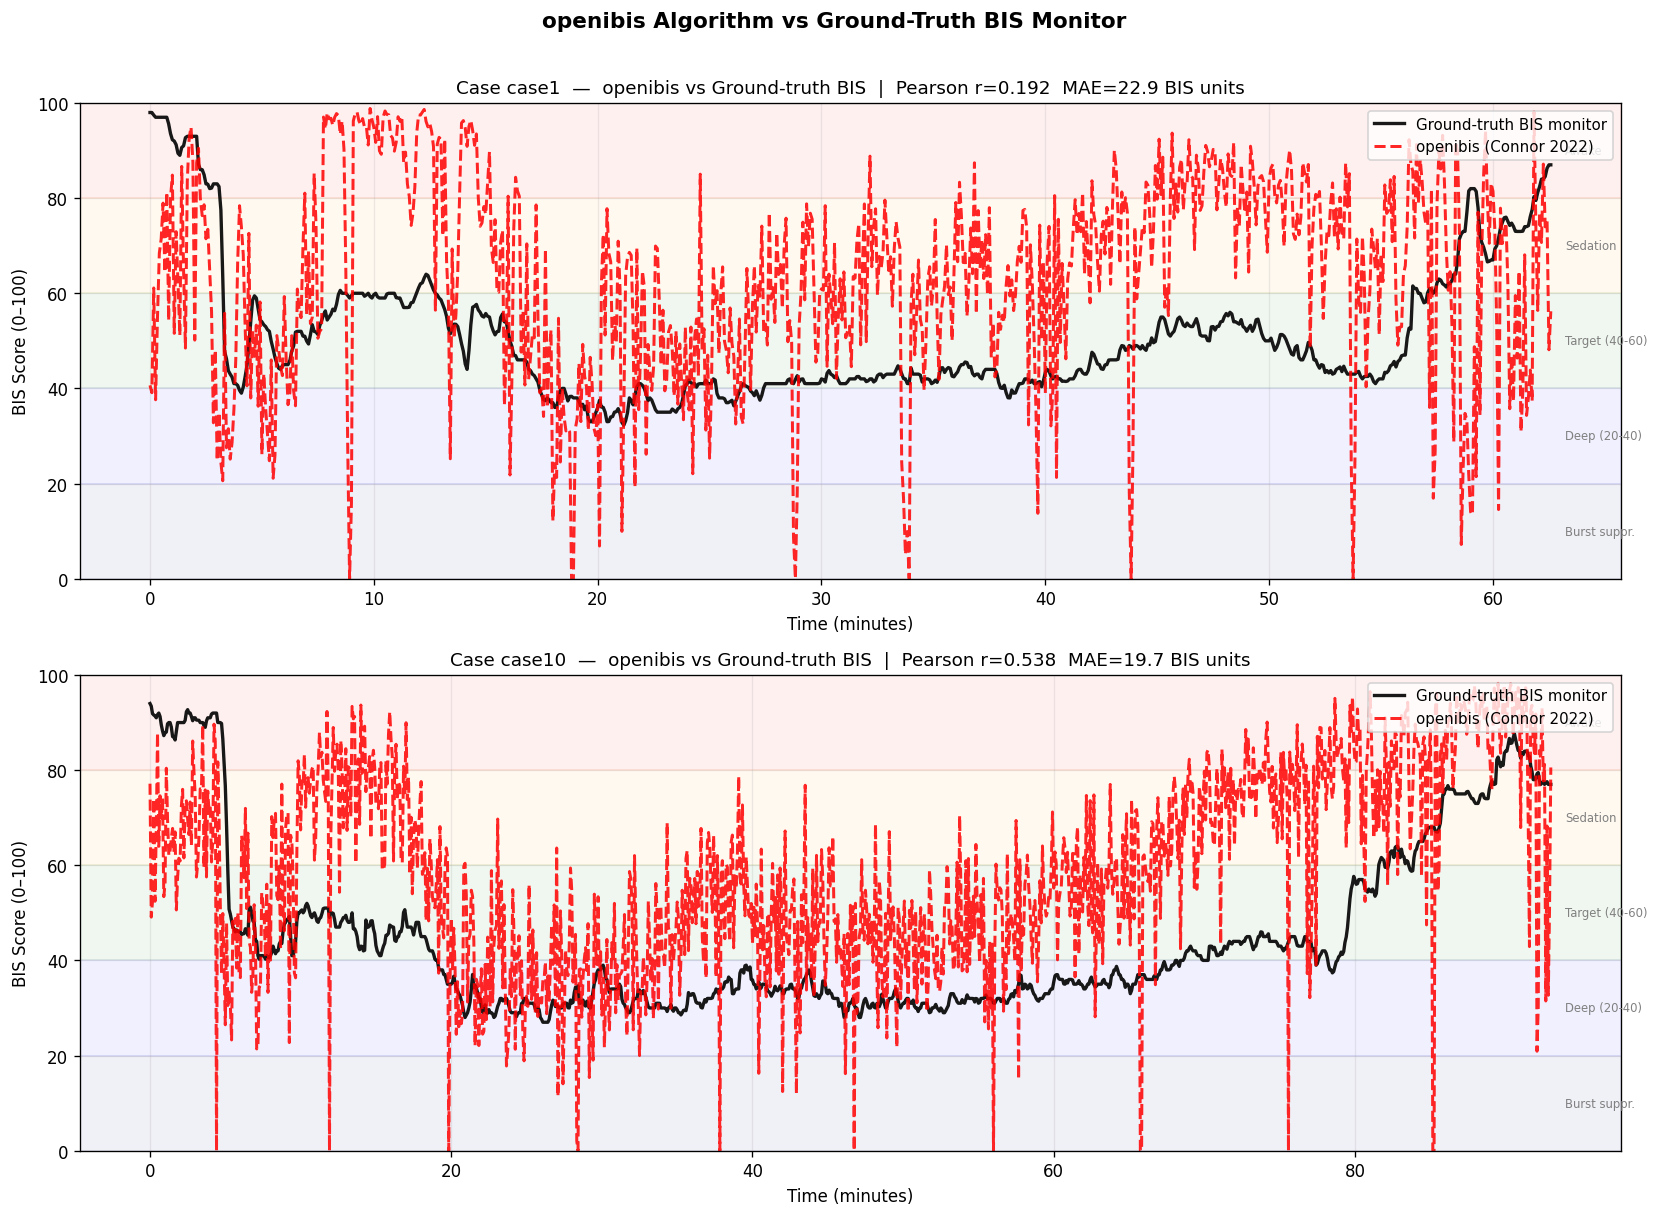

In [16]:
N_CASES = 2  # compare first 2 cases

fig, axes = plt.subplots(N_CASES, 1, figsize=(14, 5*N_CASES))
if N_CASES == 1: axes = [axes]

for ax, (cid, eeg, bis, fs) in zip(axes, cases[:N_CASES]):
    print(f'Running openibis on case {cid} ...', end=' ')
    filt   = preprocess_eeg(eeg, fs)
    # Non-overlapping 5-s epochs for cleaner time alignment
    epochs, labels = epoch_eeg(filt, bis, fs, epoch_sec=5, step_sec=5)
    if len(epochs) == 0:
        ax.set_title(f'{cid}: no epochs'); continue
    epochs, labels = reject_artifacts(epochs, labels)

    computed = np.array([openibis_score(ep, fs) for ep in epochs])
    time_min = np.arange(len(computed)) * 5 / 60.0

    # Clinical zone shading
    ax.axhspan(0,  20, alpha=0.06, color='navy')
    ax.axhspan(20, 40, alpha=0.06, color='blue')
    ax.axhspan(40, 60, alpha=0.06, color='green')
    ax.axhspan(60, 80, alpha=0.06, color='orange')
    ax.axhspan(80,100, alpha=0.06, color='red')

    ax.plot(time_min, labels,   'k-',  lw=2,   alpha=0.9, label='Ground-truth BIS monitor')
    ax.plot(time_min, computed, 'r--', lw=1.8, alpha=0.85, label='openibis (Connor 2022)')

    # Add zone labels on right
    for txt, y_pos in [('Burst suppr.', 10), ('Deep (20-40)', 30),
                        ('Target (40-60)',50), ('Sedation',70), ('Awake',90)]:
        ax.text(time_min[-1]*1.01, y_pos, txt, fontsize=7, va='center', color='gray')

    corr = np.corrcoef(labels, computed)[0, 1]
    mae  = mean_absolute_error(labels, computed)
    ax.set_title(f'Case {cid}  —  openibis vs Ground-truth BIS  '
                 f'|  Pearson r={corr:.3f}  MAE={mae:.1f} BIS units', fontsize=11)
    ax.set_xlabel('Time (minutes)', fontsize=10)
    ax.set_ylabel('BIS Score (0–100)', fontsize=10)
    ax.set_ylim(0, 100); ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.25)
    print(f'r={corr:.3f}  MAE={mae:.1f}')

plt.suptitle('openibis Algorithm vs Ground-Truth BIS Monitor', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('openibis_comparison.png', bbox_inches='tight')
plt.show()

### 6b. openibis Classification — Zone Comparison

We convert both the ground-truth BIS monitor values and the openibis-computed scores into the same 3 clinical zones, then measure zone-level agreement using a confusion matrix and classification report for 2 cases.

openibis classification comparison — case1
    Kept 752/752 epochs after artifact rejection.
  Zone accuracy : 30.7%
                   precision    recall  f1-score   support

       Deep (<40)       0.27      0.31      0.29        99
   Target (40-60)       0.67      0.24      0.35       533
Light/Awake (>60)       0.16      0.62      0.26       120

         accuracy                           0.31       752
        macro avg       0.37      0.39      0.30       752
     weighted avg       0.53      0.31      0.33       752

openibis classification comparison — case10
    Kept 1117/1239 epochs after artifact rejection.
  Zone accuracy : 35.7%
                   precision    recall  f1-score   support

       Deep (<40)       0.86      0.32      0.46       598
   Target (40-60)       0.12      0.14      0.13       326
Light/Awake (>60)       0.31      0.84      0.46       193

         accuracy                           0.36      1117
        macro avg       0.43      0.43      0.35  

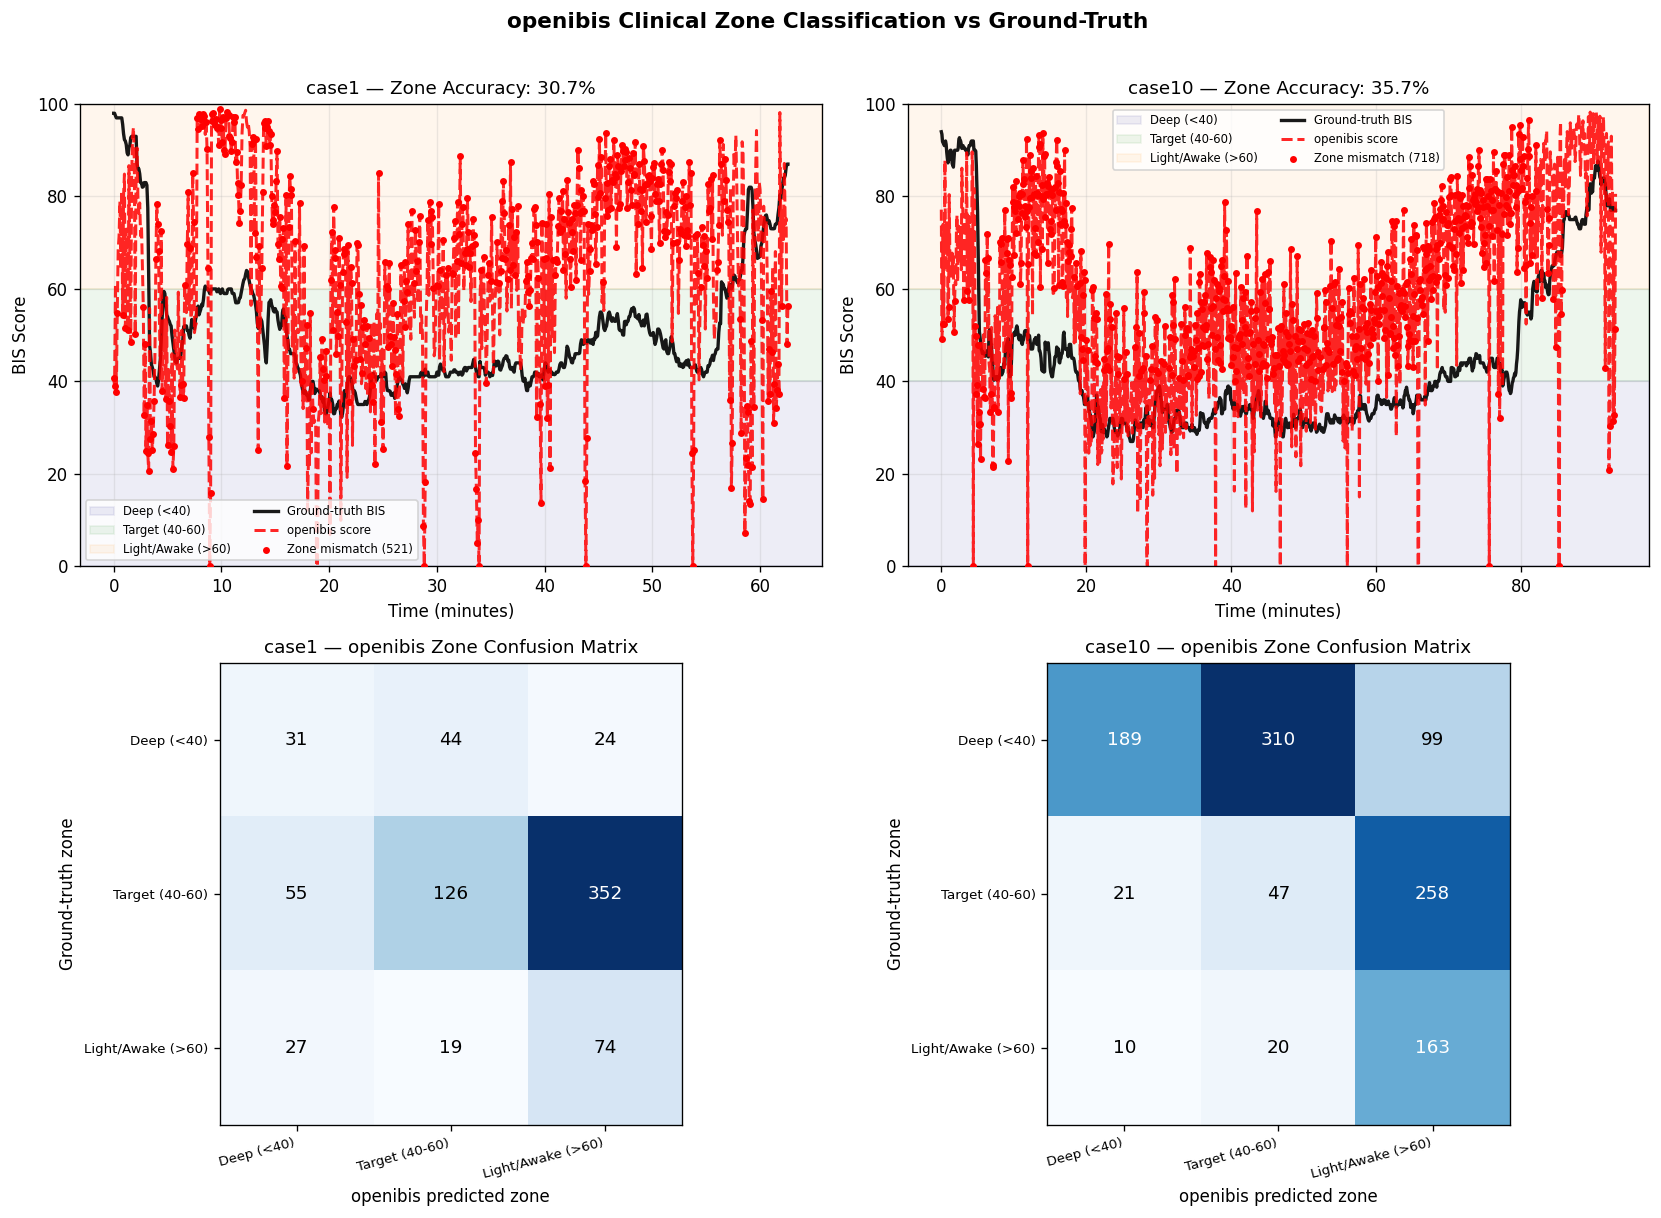

In [24]:
def bis_to_class(bis_scores):
    labels = np.zeros(len(bis_scores), dtype=int)
    labels[bis_scores >= 40] = 1
    labels[bis_scores >  60] = 2
    return labels

class_names = ["Deep (<40)", "Target (40-60)", "Light/Awake (>60)"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (cid, eeg, bis, fs) in enumerate(cases[:2]):
    print(f'openibis classification comparison — {cid}')
    filt   = preprocess_eeg(eeg, fs)
    epochs, labels = epoch_eeg(filt, bis, fs, epoch_sec=5, step_sec=5)
    epochs, labels = reject_artifacts(epochs, labels)
    computed = np.array([openibis_score(ep, fs) for ep in epochs])
    time_min = np.arange(len(computed)) * 5 / 60.0

    true_zones     = bis_to_class(labels)
    computed_zones = bis_to_class(computed)

    #Top row: time-series with zone coloring 
    ax = axes[0][idx]
    zone_colors = {0: "navy", 1: "green", 2: "darkorange"}
    ax.axhspan(0,  40, alpha=0.07, color="navy",       label="Deep (<40)")
    ax.axhspan(40, 60, alpha=0.07, color="green",      label="Target (40-60)")
    ax.axhspan(60, 100,alpha=0.07, color="darkorange",  label="Light/Awake (>60)")
    ax.plot(time_min, labels,   "k-",  lw=2,   alpha=0.9,  label="Ground-truth BIS")
    ax.plot(time_min, computed, "r--", lw=1.8, alpha=0.85, label="openibis score")

    # Mark zone disagreements
    disagree = true_zones != computed_zones
    ax.scatter(time_min[disagree], computed[disagree],
               color="red", s=10, zorder=5, label=f"Zone mismatch ({disagree.sum()})")

    acc = (true_zones == computed_zones).mean()
    ax.set_title(f"{cid} — Zone Accuracy: {acc*100:.1f}%", fontsize=11)
    ax.set_xlabel("Time (minutes)"); ax.set_ylabel("BIS Score")
    ax.set_ylim(0, 100); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.25)

    # Bottom row: confusion matrix
    ax2 = axes[1][idx]
    cm  = confusion_matrix(true_zones, computed_zones, labels=[0,1,2])
    im  = ax2.imshow(cm, cmap="Blues")
    ax2.set_xticks([0,1,2]); ax2.set_yticks([0,1,2])
    ax2.set_xticklabels(class_names, rotation=15, ha="right", fontsize=8)
    ax2.set_yticklabels(class_names, fontsize=8)
    ax2.set_xlabel("openibis predicted zone"); ax2.set_ylabel("Ground-truth zone")
    ax2.set_title(f"{cid} — openibis Zone Confusion Matrix", fontsize=11)
    for i in range(3):
        for j in range(3):
            ax2.text(j, i, str(cm[i,j]), ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=11)

    print(f"  Zone accuracy : {acc*100:.1f}%")
    print(classification_report(true_zones, computed_zones,
                                 target_names=class_names, zero_division=0))

plt.suptitle("openibis Clinical Zone Classification vs Ground-Truth",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("openibis_classification.png", bbox_inches="tight")
plt.show()

### 6c. openibis Classification — ROC, Accuracy, Full Metrics

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize

# Collect all cases (not just 2) for robust metrics
all_true_oib, all_pred_oib, all_prob_oib = [], [], []

for cid, eeg, bis, fs in cases:
    filt           = preprocess_eeg(eeg, fs)
    epochs, labels = epoch_eeg(filt, bis, fs, epoch_sec=5, step_sec=5)
    if len(epochs) == 0: continue
    epochs, labels = reject_artifacts(epochs, labels)
    computed       = np.array([openibis_score(ep, fs) for ep in epochs])

    true_zones     = bis_to_class(labels)
    computed_zones = bis_to_class(computed)

    # Soft probabilities: use computed score to build zone probabilities
    # Deep: score < 40, Target: 40-60, Light: > 60
    probs = np.zeros((len(computed), 3))
    for i, score in enumerate(computed):
        # Sigmoid-style soft assignment based on distance from boundaries
        p_deep   = 1 / (1 + np.exp( (score - 40) /  8))
        p_light  = 1 / (1 + np.exp(-(score - 60) /  8))
        p_target = max(0, 1 - p_deep - p_light)
        total    = p_deep + p_target + p_light + 1e-9
        probs[i] = [p_deep/total, p_target/total, p_light/total]

    all_true_oib.extend(true_zones)
    all_pred_oib.extend(computed_zones)
    all_prob_oib.extend(probs)

all_true_oib = np.array(all_true_oib)
all_pred_oib = np.array(all_pred_oib)
all_prob_oib = np.array(all_prob_oib)

#metrics
acc_oib = (all_true_oib == all_pred_oib).mean()
y_bin   = label_binarize(all_true_oib, classes=[0,1,2])
auc_oib = roc_auc_score(y_bin, all_prob_oib, multi_class="ovr", average="macro")

print("=" * 55)
print("openibis Classification Metrics (all 24 cases)")
print("=" * 55)
print(f"  Accuracy        : {acc_oib*100:.1f}%")
print(f"  ROC-AUC (macro) : {auc_oib:.3f}")
print()
print(classification_report(all_true_oib, all_pred_oib,
                             target_names=class_names, zero_division=0))

    Kept 752/752 epochs after artifact rejection.
    Kept 1117/1239 epochs after artifact rejection.
    Kept 1986/2550 epochs after artifact rejection.
    Kept 3242/3999 epochs after artifact rejection.
    Kept 727/815 epochs after artifact rejection.
    Kept 506/618 epochs after artifact rejection.
    Kept 2118/2617 epochs after artifact rejection.
    Kept 1331/1434 epochs after artifact rejection.
    Kept 1482/1519 epochs after artifact rejection.
    Kept 697/741 epochs after artifact rejection.
    Kept 824/871 epochs after artifact rejection.
    Kept 977/977 epochs after artifact rejection.
    Kept 1834/1949 epochs after artifact rejection.
    Kept 1555/1858 epochs after artifact rejection.
    Kept 428/462 epochs after artifact rejection.
    Kept 1164/1164 epochs after artifact rejection.
    ⚠ Artifact rejection skipped (signal may not be in µV).
    Kept 2551/2557 epochs after artifact rejection.
    Kept 715/779 epochs after artifact rejection.
    Kept 389/475 epo

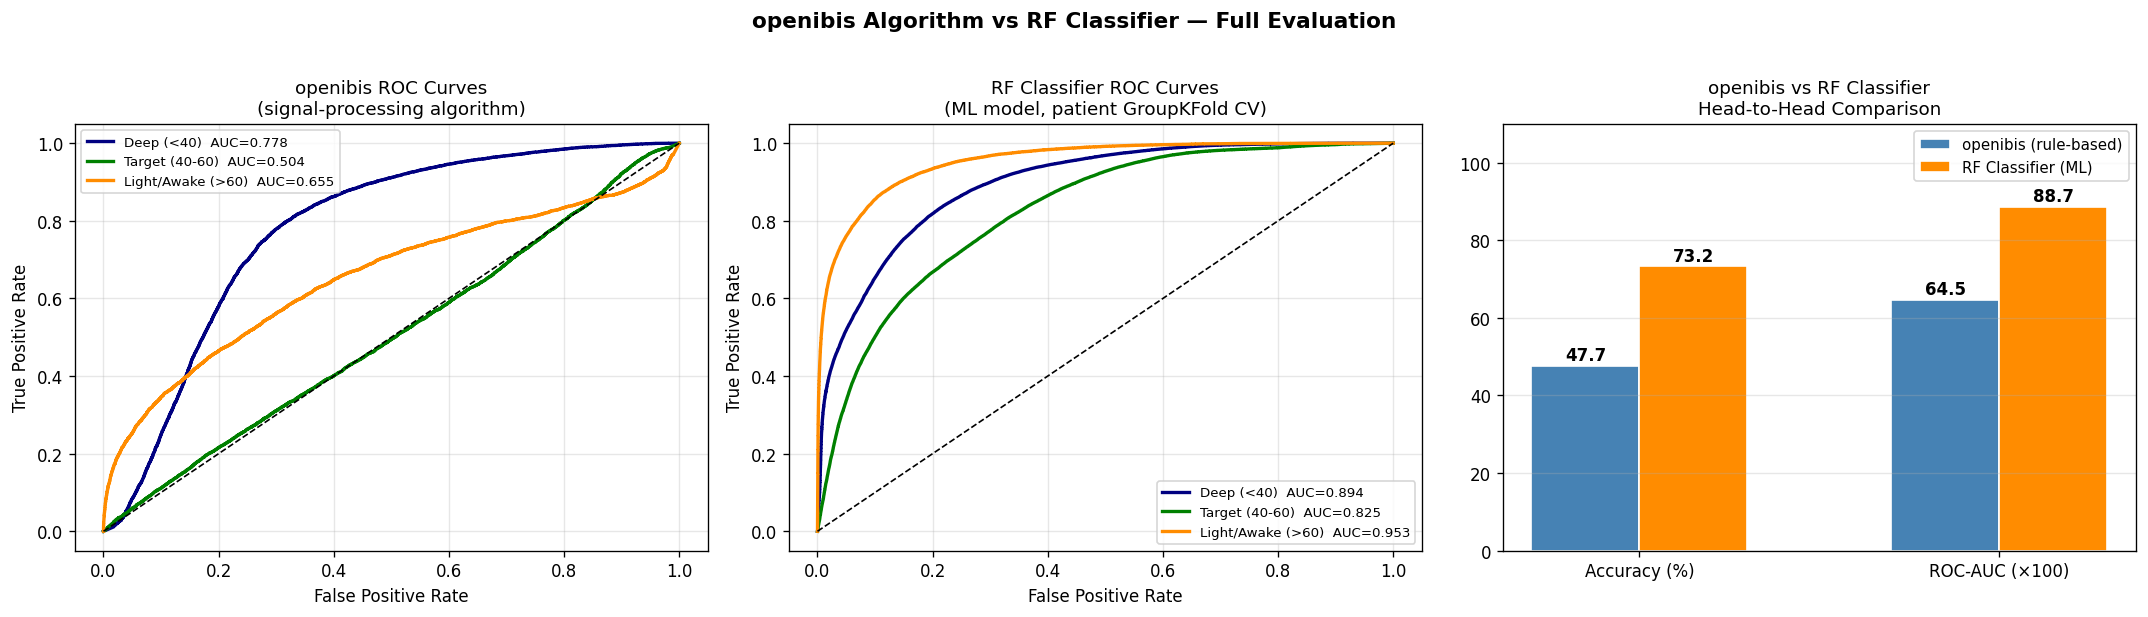


Summary:
  openibis  →  Accuracy=47.7%   ROC-AUC=0.645  (no training needed)
  RF Model  →  Accuracy=73.2%   ROC-AUC=0.887  (trained on patient data)


In [26]:
# ROC + Accuracy comparison openibis vs RF classifier ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
roc_colors = ["navy", "green", "darkorange"]

# openibis ROC curves
for i, (name, color) in enumerate(zip(class_names, roc_colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_prob_oib[:, i])
    auc_i = roc_auc_score(y_bin[:, i], all_prob_oib[:, i])
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name}  AUC={auc_i:.3f}")
axes[0].plot([0,1],[0,1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("openibis ROC Curves\n(signal-processing algorithm)", fontsize=11)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Panel B: RF Classifier ROC curves
y_bin_rf = label_binarize(all_true_c, classes=[0,1,2])
for i, (name, color) in enumerate(zip(class_names, roc_colors)):
    fpr, tpr, _ = roc_curve(y_bin_rf[:, i], all_prob_c[:, i])
    auc_i = roc_auc_score(y_bin_rf[:, i], all_prob_c[:, i])
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f"{name}  AUC={auc_i:.3f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("RF Classifier ROC Curves\n(ML model, patient GroupKFold CV)", fontsize=11)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Head-to-head accuracy + AUC bar chart
acc_rf  = np.mean(acc_list)
auc_rf  = np.mean(auc_list)

x      = np.arange(2)
width  = 0.3
bars1  = axes[2].bar(x - width/2, [acc_oib*100, auc_oib*100],
                      width, label="openibis (rule-based)", color="steelblue",  edgecolor="white")
bars2  = axes[2].bar(x + width/2, [acc_rf*100,  auc_rf*100],
                      width, label="RF Classifier (ML)",   color="darkorange", edgecolor="white")

for bar in list(bars1) + list(bars2):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")

axes[2].set_xticks(x)
axes[2].set_xticklabels(["Accuracy (%)", "ROC-AUC (×100)"], fontsize=10)
axes[2].set_ylim(0, 110)
axes[2].set_title("openibis vs RF Classifier\nHead-to-Head Comparison", fontsize=11)
axes[2].legend(fontsize=9); axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("openibis Algorithm vs RF Classifier — Full Evaluation",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("openibis_vs_rf_comparison.png", bbox_inches="tight")
plt.show()

print(f"\nSummary:")
print(f"  openibis  →  Accuracy={acc_oib*100:.1f}%   ROC-AUC={auc_oib:.3f}  (no training needed)")
print(f"  RF Model  →  Accuracy={acc_rf*100:.1f}%   ROC-AUC={auc_rf:.3f}  (trained on patient data)")

## 7. Summary & Discussion

In [28]:
print('Summary:')
print(f'  Dataset         : {len(cases)} cases, {len(y)} total epochs')
print(f'  Features        : {X.shape[1]} per 5-s epoch')

print('Regression (Random Forest)')
print(f'  MAE             : {metrics["MAE"]:.2f} ± {metrics["MAE_std"]:.2f} BIS units')
print(f'  RMSE            : {metrics["RMSE"]:.2f} ± {metrics["RMSE_std"]:.2f} BIS units')
print(f'  R²              : {metrics["R2"]:.3f} ± {metrics["R2_std"]:.3f}')

print('Classification (Random Forest)')
print(f'  Accuracy        : {np.mean(acc_list)*100:.1f}% ± {np.std(acc_list)*100:.1f}%')
print(f'  ROC-AUC (macro) : {np.mean(auc_list):.3f} ± {np.std(auc_list):.3f}')

print('openibis Algorithm (Connor 2022, no training)')
print(f'  Accuracy        : {acc_oib*100:.1f}%')
print(f'  ROC-AUC (macro) : {auc_oib:.3f}')

print('RF vs openibis Gap')
print(f'  Accuracy gain   : +{(np.mean(acc_list) - acc_oib)*100:.1f}% (ML over rule-based)')
print(f'  AUC gain        : +{np.mean(auc_list) - auc_oib:.3f}')

Summary:
  Dataset         : 24 cases, 148376 total epochs
  Features        : 14 per 5-s epoch
Regression (Random Forest)
  MAE             : 6.43 ± 0.76 BIS units
  RMSE            : 9.66 ± 1.33 BIS units
  R²              : 0.664 ± 0.083
Classification (Random Forest)
  Accuracy        : 73.2% ± 6.8%
  ROC-AUC (macro) : 0.887 ± 0.030
openibis Algorithm (Connor 2022, no training)
  Accuracy        : 47.7%
  ROC-AUC (macro) : 0.645
RF vs openibis Gap
  Accuracy gain   : +25.5% (ML over rule-based)
  AUC gain        : +0.241


## Discussion

### What the results show

The pipeline achieved **MAE = 6.4 BIS units** and **R² = 0.664** on regression, 
and **73.2% accuracy / ROC-AUC = 0.887** on classification — both evaluated on 
held-out patients via GroupKFold, making these realistic out-of-sample estimates.

The openibis algorithm, with **no training at all**, reached 47.7% accuracy and 
ROC-AUC = 0.645 — a meaningful baseline given it uses only 4 fixed spectral 
coefficients. The RF gains **+25.5% accuracy and +0.241 AUC** by learning from 
labelled data.

Notably, from the feature correlation plot, **SampEn and SEF95 had the highest 
Pearson r with BIS (~0.6)**, while from the RF importance plot **rel_gamma and 
log_gamma_lo dominated** — consistent with Connor (2022)'s finding that 
low-γ (30–47 Hz) is the primary BIS driver, not true bispectral features.

The regression MAE by zone bar chart (Section 5b) shows the regressor struggles 
most in the **Deep zone (MAE = 10.5)** — this is where burst suppression creates 
near-isoelectric EEG that is hard to differentiate from other deep states without 
BSR.

### What didn't work / Limitations

- openibis coefficients are heuristic — the proprietary Aspect Medical weights 
  are unpublished, explaining the MAE ~20 BIS units vs ground truth
- 24 cases is a small cohort; fold-level accuracy ranged from 61–80%, showing 
  high variance
- Single frontal EEG channel; commercial BIS uses 4 electrodes with spatial 
  averaging
- No temporal smoothing — the real BIS monitor applies a 15–30 s rolling window; 
  our epoch predictions are noisier

### What I'd explore next

1. **LSTM / GRU** — capture induction → maintenance → emergence state transitions 
   that RF treats as independent epochs
2. **Per-patient z-score normalisation** — EEG amplitude varies 5–10× between 
   patients; within-patient normalisation would reduce inter-subject variance
3. **Calibrate openibis coefficients** — fit the 4 spectral weights by minimising 
   MAE on this dataset; a 4-parameter regression on top of the signal features
4. **Cross-frequency coupling** — θ-γ phase-amplitude coupling (PAC) decreases 
   under anesthesia and is not captured by marginal power features
5. **Leave-one-subject-out (LOSO)** — stricter than GroupKFold; gives the most 
   conservative and realistic estimate for clinical deployment

### References

- Connor CW (2022). *Open Reimplementation of the BIS Algorithms for Depth of 
  Anesthesia.* Anesthesia & Analgesia, 135(4):855-864. PMID: 35767469
- Li Ma (2017). EEG and BIS raw data. figshare. 
  https://doi.org/10.6084/m9.figshare.5589841